In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import sys

import src.utils.utils as utils
import src.utils.losses as losses
import src.utils.plots as plots
import src.utils.extractor as extractor
import src.models.models as models

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

Using device: cuda:0


In [27]:
display_losses = False

dataset = "apex"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.to(torch.float32)
Y_init = Y_init.unsqueeze(0)

### SiVM + FCLS

SAD = 0.244 ± 0.00, SAD (A) = 0.956 ± 0.00, NMSE = 0.857 ± 0.00


<Figure size 640x480 with 0 Axes>

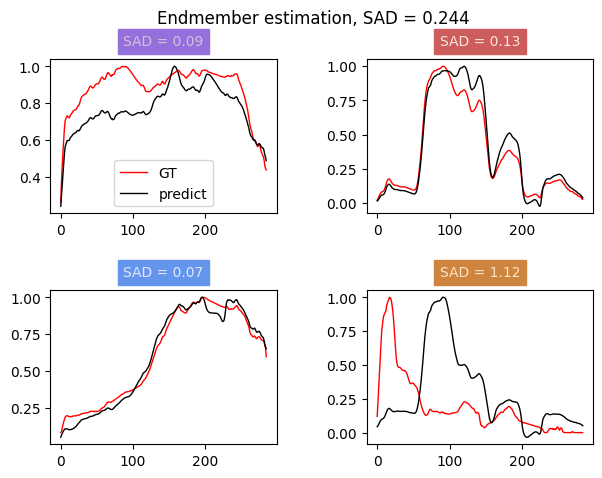

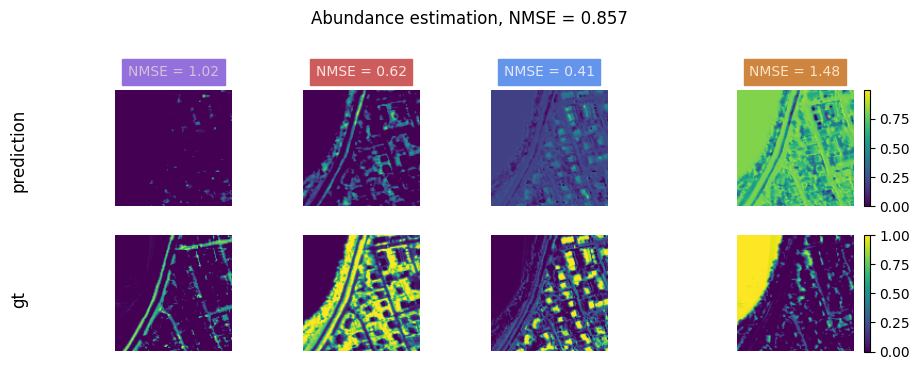

In [ ]:
n_xp = 5
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path="/home/edabier/Documents/Thèse/benchmark")
sads, sads_a, mses = [], [], []

for n in range(n_xp):
    for Y, E, A in loader:
        Y = Y.squeeze(0)

        E_hat = extractor.SiVM(Y, c)
        A_hat = extractor.FCLS(Y, E_hat)

        A_hat = utils.oneD_to_2d(A_hat)
        A = utils.oneD_to_2d(A)
        break
    sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A, E, normalise_E=True, return_results=True, plot_A=False, plot_E=False)
    sads.append(sad)
    sads_a.append(sad_a)
    mses.append(mse)

sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A, E, normalise_E=True, return_results=True)
print(f"SAD = {format(torch.mean(torch.tensor(sads)), ".3f")} ± {format(torch.std(torch.tensor(sads)), ".2f")}, SAD (A) = {format(torch.mean(torch.tensor(sads_a)), ".3f")} ± {format(torch.std(torch.tensor(sads_a)), ".2f")}, NMSE = {format(torch.mean(torch.tensor(mses)), ".3f")} ± {format(torch.std(torch.tensor(mses)), ".2f")}")

### CNNAEU

In [29]:
class CNNAEU2(nn.Module):
    def __init__(self, B, c, H, E_init=None, use_cnn=False):
        super().__init__()

        self.B = B
        self.c = c
        self.H = H
        self.use_cnn = use_cnn

        self.encoder = nn.Sequential(
            nn.Conv2d(self.B, 48, kernel_size=3, padding=1, padding_mode="reflect", bias=False),
            nn.LeakyReLU(),
            nn.BatchNorm2d(48),
            nn.Dropout2d(p=0.2),
            nn.Conv2d(48, self.c, kernel_size=1, bias=False),
            nn.LeakyReLU(),
            nn.BatchNorm2d(self.c),
            nn.Dropout2d(p=0.2),
        )
        self.decoder = nn.Conv2d(self.c, self.B, kernel_size=11, padding=5, padding_mode="reflect", bias=False)

        if E_init != None:
            state_dict = self.decoder.state_dict()
            state_dict["weight"] = E_init.unsqueeze(-1).unsqueeze(-1).expand(self.B, self.c, 11, 11)
            self.decoder.load_state_dict(state_dict)

        if self.use_cnn:
            self.norm = nn.LayerNorm([self.B, self.H, self.H])
            self.encoder2 = nn.Sequential(
                nn.Conv2d(self.B, 48, kernel_size=3, padding=1, padding_mode="reflect", bias=False),
                nn.LeakyReLU(),
                nn.Dropout2d(p=0.2),
                nn.Conv2d(48, self.c, kernel_size=1, bias=False),
                nn.LeakyReLU(),
                nn.Dropout2d(p=0.2),
            )
            self.decoder2 = nn.Conv2d(self.c, self.B, kernel_size=11, padding=5, padding_mode="reflect", bias=False)

        else:
            self.encoder2 = nn.Linear(self.B, self.c)
            self.decoder2 = nn.Linear(self.c, self.B, bias=False)   
    
    def freeze1(self):
        # Freeze first part
        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.decoder.parameters():
            param.requires_grad = False

        # Unfreeze second encoder
        for param in self.encoder2.parameters():
            param.requires_grad = True
        for param in self.decoder2.parameters():
            param.requires_grad = False

    def freeze2(self):
        # Freeze second part
        for param in self.encoder2.parameters():
            param.requires_grad = False
        for param in self.decoder2.parameters():
            param.requires_grad = False

        # Unfreeze first part
        for param in self.encoder.parameters():
            param.requires_grad = True
        for param in self.decoder.parameters():
            param.requires_grad = True
    
    @staticmethod
    def loss(E_gt, E_hat, A_gt, A_hat, Y_gt, Y_hat):
        sad = losses.SADLoss()
        return sad(Y_gt, Y_hat)
    
    def forward1(self, x):
        # Input shape (batch, B, N)
        
        if x.dim() < 3:
            x = x.unsqueeze(0) # Add a batch dimension for inference
        
        batch, B, N = x.shape
        x = utils.oneD_to_2d(x)
        code = self.encoder(x)
        
        abund = F.softmax(code, dim=1)
        a_hat = abund.reshape(batch, self.c, N)
        
        x_hat = self.decoder(abund)
        x_hat = x_hat.reshape(batch, B, N)
        
        e_hat = self.decoder.weight.detach().mean((2, 3)).reshape(batch, self.B, self.c)
        
        return e_hat, a_hat, x_hat

    def forward2(self, x):
        
        if x.dim() < 3:
            x = x.unsqueeze(0)

        if self.use_cnn:
            batch, _, N = x.shape
            x = utils.oneD_to_2d(x)
            x = x/torch.max(x)

            code = self.encoder2(x)
            A_hat = F.softmax(code, dim=1)
            Y_hat = self.decoder2(A_hat)

            A_hat = A_hat.reshape(batch, self.c, N)
            Y_hat = Y_hat.reshape(batch, self.B, N)

            E_hat = self.decoder2.weight.detach().mean((2, 3)).reshape(batch, self.B, self.c)

        else:
            batch, _, N = x.shape
            x_reshaped = x.permute(0, 2, 1).reshape(-1, self.B)
            A_hat = self.encoder2(x_reshaped)
            A_hat = F.softmax(A_hat)
            Y_hat = self.decoder2(A_hat)
            E_hat = self.decoder2.weight    

            A_hat = A_hat.view(batch, N, self.c).permute(0, 2, 1)
            Y_hat = Y_hat.view(batch, N, self.B).permute(0, 2, 1)

        return E_hat, A_hat, Y_hat

1 xp done
2 xp done
3 xp done
4 xp done
5 xp done
SAD = 0.489 ± 0.01, SAD (A) = 0.754 ± 0.17, NMSE = 0.801 ± 0.30


<Figure size 640x480 with 0 Axes>

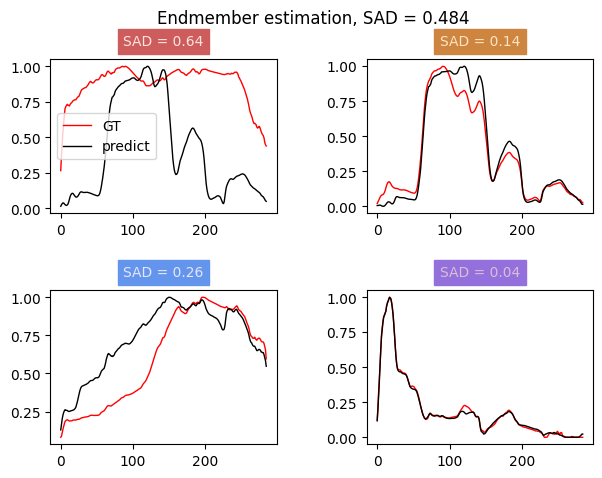

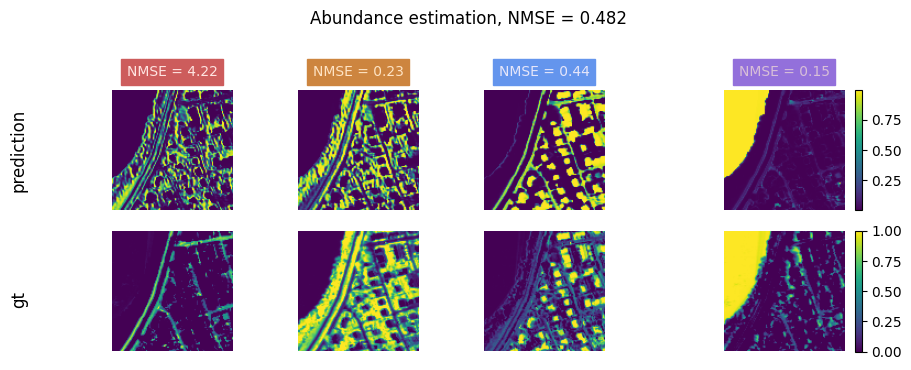

In [ ]:
n_xp = 5
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path="/home/edabier/Documents/Thèse/benchmark")
sads, sads_a, mses = [], [], []

for n in range(n_xp):

    E_init = extractor.SiVM(Y_init/Y_init.max(), c)
    # E_init = utils.normalise(E_init, is_endmember=True)
    model = CNNAEU2(B, c, H=Y_init.shape[2], E_init=E_init, use_cnn=False)
    model.freeze2()

    train_losses = []

    epochs, lr = 500, 0.01
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)

    for epoch in range(epochs):
        
        train_loss = 0
        
        for Y, E, A in loader:
            optimizer.zero_grad()
            
            Y = Y.to(dev)
            A = A.to(dev)
            E = E.to(dev)

            E_hat, A_hat, Y_hat = model.forward1(Y)
            
            loss = model.loss(E, E_hat, A, A_hat, Y, Y_hat)
            train_loss += loss.item()

            if display_losses:
                if epoch%(epochs//10)==0:
                    print(f"Epoch {epoch}: total = {format(loss, '.3f')}")
            
            loss.backward()
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
            break

        train_loss /= len(loader)
        train_losses.append(train_loss)

    E_hat_cnn, A_hat_cnn, Y_hat_cnn = model.forward1(Y)
    A_hat_cnn = utils.oneD_to_2d(A_hat_cnn)
    A = utils.oneD_to_2d(A)
    sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_cnn, A_hat_cnn, A, E, normalise_E=True, return_results=True, plot_A=False, plot_E=False)
    sads.append(sad)
    sads_a.append(sad_a)
    mses.append(mse)
    print(f"{n+1} xp done")

sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_cnn, A_hat_cnn, A, E, normalise_E=True, return_results=True)
print(f"SAD = {format(torch.mean(torch.tensor(sads)), ".3f")} ± {format(torch.std(torch.tensor(sads)), ".2f")}, SAD (A) = {format(torch.mean(torch.tensor(sads_a)), ".3f")} ± {format(torch.std(torch.tensor(sads_a)), ".2f")}, NMSE = {format(torch.mean(torch.tensor(mses)), ".3f")} ± {format(torch.std(torch.tensor(mses)), ".2f")}")

### CNNAEU 2

Epoch 0: total = 0.674
Epoch 40: total = 0.375
Epoch 80: total = 0.361
Epoch 120: total = 0.355
Epoch 160: total = 0.356
Epoch 200: total = 0.369
Epoch 240: total = 0.366
Epoch 280: total = 0.377
Epoch 320: total = 0.117
Epoch 360: total = 0.125


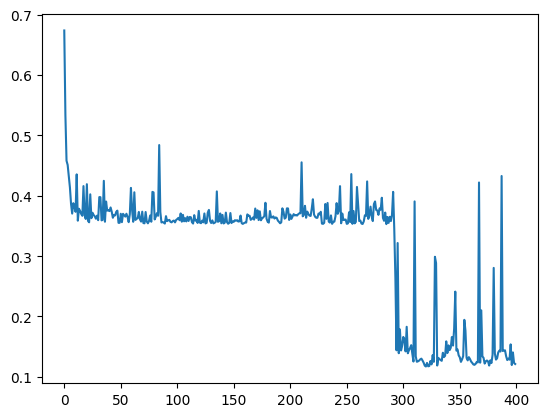

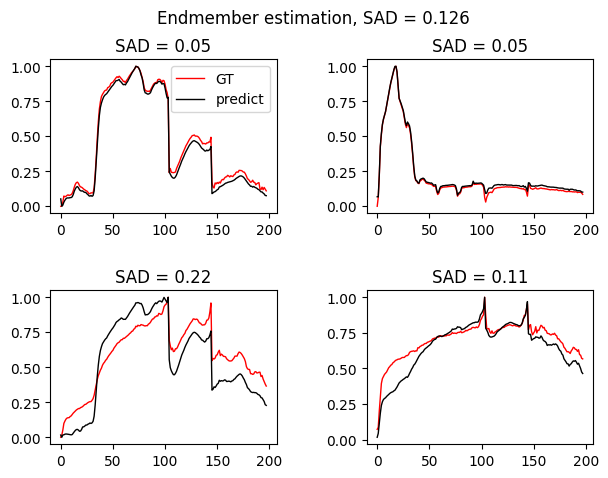

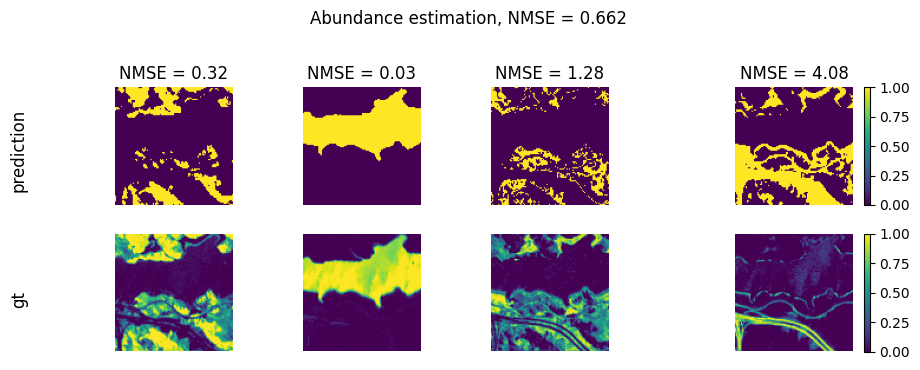

In [ ]:
model.freeze1()
state_dict = model.decoder2.state_dict()
state_dict["weight"] = model.decoder.weight.detach().mean((2, 3)).reshape(B, c)
# state_dict["weight"] = model.decoder.weight
# state_dict["decoder.weight"][:, :, 0, 0] = model.decoder.get_endmembers()

model.decoder2.load_state_dict(state_dict)

train_losses = []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev)

epochs, lr = 400, 0.001
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

for epoch in range(epochs):
    
    train_loss = 0
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = Y.to(dev)
        A = A.to(dev)
        E = E.to(dev)

        _, _, Y1 = model.forward1(Y)
        E_hat, A_hat, Y_hat = model.forward2(Y1)
        
        loss = model.loss(E, E_hat, A, A_hat, Y, Y_hat)
        train_loss += loss.item()

        if display_losses:
            if epoch%(epochs//10)==0:
                print(f"Epoch {epoch}: total = {format(loss, '.3f')}")
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        break

    train_loss /= len(loader)
    train_losses.append(train_loss)
plt.plot(train_losses)

E_hat_cnn, A_hat_cnn, Y_hat_cnn = model.forward2(Y)
A = utils.oneD_to_2d(A)
A_hat_cnn = utils.oneD_to_2d(A_hat_cnn)
utils.plot_results(E_hat_cnn, A_hat_cnn, A, E, normalise_E=True)

In [229]:
print("The unmixer model has : ", format(sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6, '.2f'), "M trainable params")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, ': ', format(param.numel()/1e3, '.2f'), "k params")

The unmixer model has :  0.00 M trainable params
encoder2.weight :  0.79 k params
encoder2.bias :  0.00 k params
